# **Fase 1: Análisis Exploratorio (EDA)**
Estudiante: Maria Camila Navarrete Pinzón

Código: 2294353

Fecha: 04 febrero, 2026

# Notebook 02: Análisis Exploratorio

Este cuaderno tiene como objetivo entender la distribución de las variables, identificar valores nulos y outliers.

**Actividades**:

- Cargar datos desde parquet
- Calcular estadísticas descriptivas
- Análizar distribución por departamento
- Identificar valores faltantes
- Detectar outliers en valores de contratosntratos

In [66]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, sum as spark_sum, avg, min as spark_min,
    max as spark_max, stddev, isnan, when, isnull, desc
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Configuración de SparkSession

Se crea una sesión de spark configurada para ejecutarse en modo local, asignando memoria al driver.

In [67]:
spark = SparkSession.builder \
    .appName("SECOP_EDA") \
    .master("local[*]") \
    .config("spark.executor.memory", "2g") \
    .getOrCreate()

print(f"Spark Version: {spark.version}")

Spark Version: 3.5.0


## 2. Carga de datos

In [68]:
parquet_path = "/opt/spark-data/raw/secop_contratos.parquet"
print(f"Cargando datos desde: {parquet_path}")

df = spark.read.parquet(parquet_path)
print(f"Registros cargados: {df.count():,}")
print(f"Columnas: {len(df.columns)}")

Cargando datos desde: /opt/spark-data/raw/secop_contratos.parquet


Registros cargados: 52,248
Columnas: 9


## 3. Estructura general de los datos

In [69]:
print("\nEsquema del dataset")
df.printSchema()

print("\nPrimeras 10 filas")
df.show(10, truncate=True)


Esquema del dataset
root
 |-- referencia_del_contrato: string (nullable = true)
 |-- nit_entidad: string (nullable = true)
 |-- nombre_entidad: string (nullable = true)
 |-- departamento: string (nullable = true)
 |-- ciudad: string (nullable = true)
 |-- tipo_de_contrato: string (nullable = true)
 |-- valor_del_contrato: string (nullable = true)
 |-- fecha_de_firma: string (nullable = true)
 |-- estado_contrato: string (nullable = true)


Primeras 10 filas
+-----------------------+-----------+--------------------+--------------------+-------------+--------------------+------------------+--------------------+---------------+
|referencia_del_contrato|nit_entidad|      nombre_entidad|        departamento|       ciudad|    tipo_de_contrato|valor_del_contrato|      fecha_de_firma|estado_contrato|
+-----------------------+-----------+--------------------+--------------------+-------------+--------------------+------------------+--------------------+---------------+
|   CONTRATO 3778 DEL...

## 4. Estadísticas descriptivas y exploratorias

En esta sección se hace una exploración de los datos por medio de diferentes gráficos que permiten análisar diversas características del negocio. 

In [70]:
print("\nEstadísticas descriptivas")
df.describe().show()


Estadísticas descriptivas


+-------+-----------------------+--------------------+--------------------+------------+-------------+--------------------+--------------------+--------------------+---------------+
|summary|referencia_del_contrato|         nit_entidad|      nombre_entidad|departamento|       ciudad|    tipo_de_contrato|  valor_del_contrato|      fecha_de_firma|estado_contrato|
+-------+-----------------------+--------------------+--------------------+------------+-------------+--------------------+--------------------+--------------------+---------------+
|  count|                  52248|               52248|               52248|       52248|        52248|               52248|               52248|               52248|          52248|
|   mean|   7.538696532103921E11|1.7508727405400398E9|                NULL|        NULL|         NULL|                NULL|5.2151670054863346E8|                NULL|           NULL|
| stddev|   3.758888652006574E12| 2.491470594707039E9|                NULL|        NULL|  

### 4.1 Distribución del valor del contrato 

Este gráfico muestra la distribución del valor de los contratos utilizando una transformación logaritmica (log10), lo que permite analizar adecuadamente la alta dispersión de los montos contractuales. Se destacan la mediana y los percentiles 25 y 75 para identificar la concentración central de los valores y la presencia de contratos atípicos de alto valor.

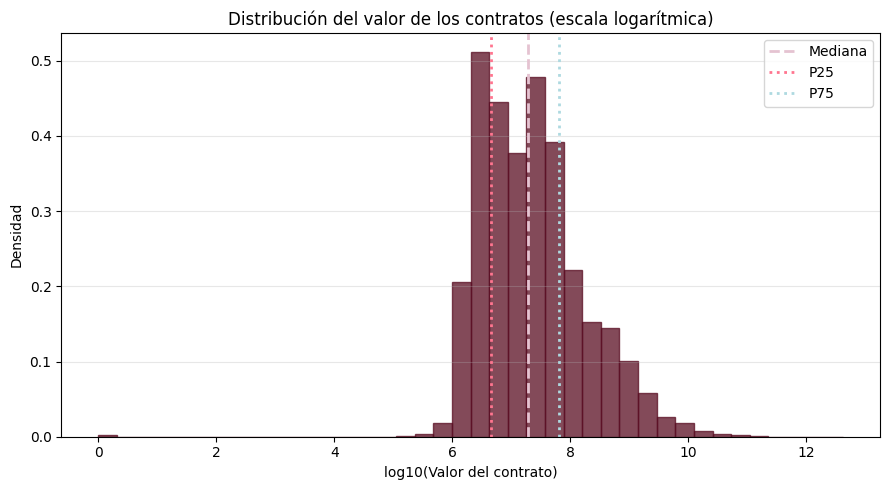

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql.functions import col

df_valor = (
    df.withColumn("valor_num", col("valor_del_contrato").cast("double"))
      .filter(col("valor_num").isNotNull())
      .filter(col("valor_num") > 0)
)

valor_pd = df_valor.select("valor_num").toPandas()

valor_pd["log_valor"] = np.log10(valor_pd["valor_num"])
median = valor_pd["log_valor"].median()
q1 = valor_pd["log_valor"].quantile(0.25)
q3 = valor_pd["log_valor"].quantile(0.75)


plt.figure(figsize=(9, 5))

plt.hist(
    valor_pd["log_valor"],
    bins=40,
    density=True,
    color="#590d22",      # SlateBlue
    alpha=0.75,
    edgecolor="#590d22"
)


plt.axvline(median, color="#e5c3d1", linestyle="--", linewidth=2, label="Mediana")
plt.axvline(q1, color="#ff758f", linestyle=":", linewidth=2, label="P25")
plt.axvline(q3, color="#aed9e0", linestyle=":", linewidth=2, label="P75")


plt.xlabel("log10(Valor del contrato)")
plt.ylabel("Densidad")
plt.title("Distribución del valor de los contratos (escala logarítmica)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


La distribución del valor de los contratos, tras aplicar una transformación logarítmica, evidencia una fuerte concentración en rangos medios y una cola larga hacia valores elevados. La cercania entre los percentiles 25 y 75 indica una dispersión moderada en el núcleo de los datos, por otro lado la presencia de valores extremos sugiere la existencia de contratos atípicos de alto valor, caracteristicos de procesos de contratación pública. Estos resultados justifican el uso de transformaciones logarítmicas y técnicas robustas en fases posteriores del modelado.  

### 4.2 Número de contratos por tipo de contrato (Top 10)

Este gráfico muestra los tipos de contrato más frecuentes en el dataset. Permitiendo identificar patrones de contratación y posibles concentraciones en determinadas modalidades contractuales.

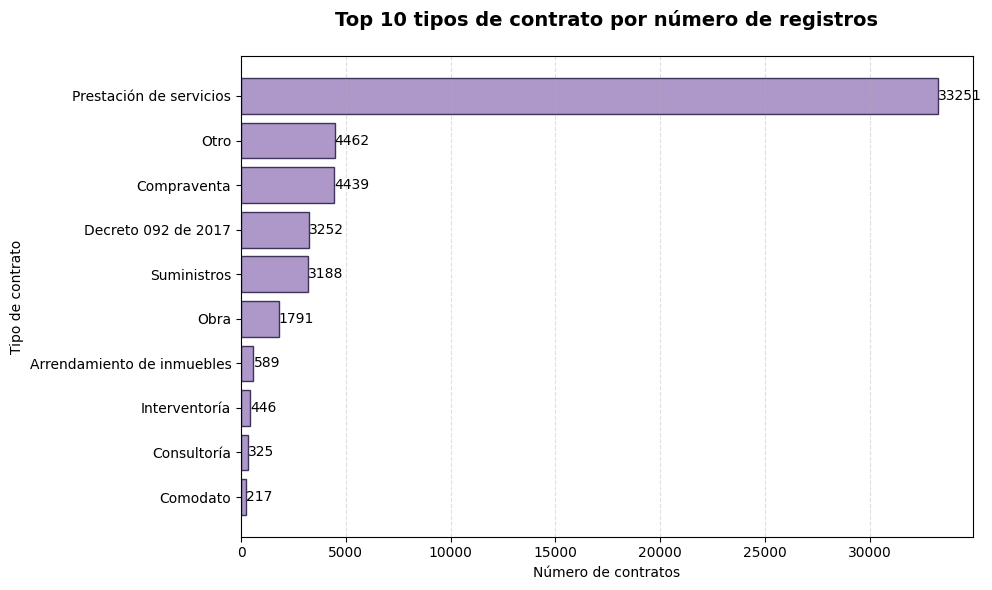

In [72]:
import matplotlib.pyplot as plt

top_contratos = (
    df.groupBy("tipo_de_contrato")
      .count()
      .orderBy("count", ascending=False)
      .limit(10)
      .toPandas()
)


top_contratos = top_contratos.sort_values("count")


plt.figure(figsize=(10, 6))
bars = plt.barh(
    top_contratos["tipo_de_contrato"],
    top_contratos["count"],
    color="#9f86c0",
    edgecolor="#231942",
    alpha=0.85
)

# Etiquetas de valor
for bar in bars:
    plt.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center'
    )

plt.title(
    "Top 10 tipos de contrato por número de registros\n",
    fontsize=14,
    weight="bold"
)
plt.xlabel("Número de contratos")
plt.ylabel("Tipo de contrato")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()



El gráfico evidencia su mayor concentración de contratos en la modalidad de prestación de servicios, con más de 33000 registros, lo que representa la gran mayoría del total de contratos analizados. Este patrón sugiere que las entidades públicas priorizan esquemas flexibles, orientados a la contratación de servicios por un periodo definido. En conjunto, la distribución muestra una alta dependencia de un solo tipo de contrato, lo que puede ser relevante para el análisis de planeación presupuestal y/o políticas de contratación públicas. 

### 4.3 Estado del contrato vs número de contratos

Se analiza el estado de los contratos para comprender el ciclo de vida contractual predominante en el dataset y el nivel de ejecución de los mismos. 

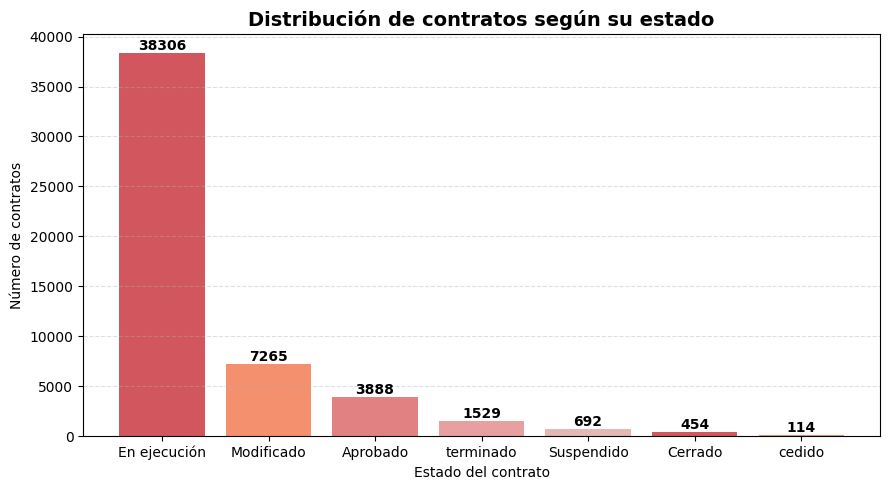

In [73]:
import matplotlib.pyplot as plt
estado_df = (
    df.groupBy("estado_contrato")
      .count()
      .orderBy("count", ascending=False)
      .toPandas()
)
plt.figure(figsize=(9, 5))
colors = [
    "#cc444b",  
    "#f4845f", 
    "#df7373",  
    "#e39695",
    "#e4b1ab"  
]
bars = plt.bar(
    estado_df["estado_contrato"],
    estado_df["count"],
    color=colors[:len(estado_df)],
    alpha=0.9
)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )
plt.title(
    "Distribución de contratos según su estado",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Estado del contrato")
plt.ylabel("Número de contratos")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

El resultado evidencia una alta concentración de contratos en estado “En ejecución”, lo que representa la gran mayoría del dataset. Esto sugiere que la base está compuesta principalmente por contratos activos, lo cual es coherente si el corte de datos corresponde procesos aún vigentes. En segundo lugar aparecen los contratos Modificados, una proporción relevante que indica que una parte significativa de los contratos ha sufrido ajustes posteriores a su firma inicial (plazos, valores, condiciones), lo cual es un hallazgo importante para análisis. Los estados Aprobado, Cedido, Terminado y Suspendido, representan fracciones mucho menores del total, mostrando que los contratos cerrados o excepcionalmente detenidos son poco frecuentes en esta muestra. 

### 4.4 Relación entre tipo de contrato y estado del contrato

Este gráfico es de  caracter multidimensional y muestra un conteo del estado de cada uno de los tipos de contrato. Esto para hacer un análisis más profundo. 

In [74]:
from pyspark.sql.functions import col

heatmap_df = (
    df
    .groupBy("tipo_de_contrato", "estado_contrato")
    .count()
    .toPandas()
)

pivot_heatmap = heatmap_df.pivot(
    index="tipo_de_contrato",
    columns="estado_contrato",
    values="count"
).fillna(0)


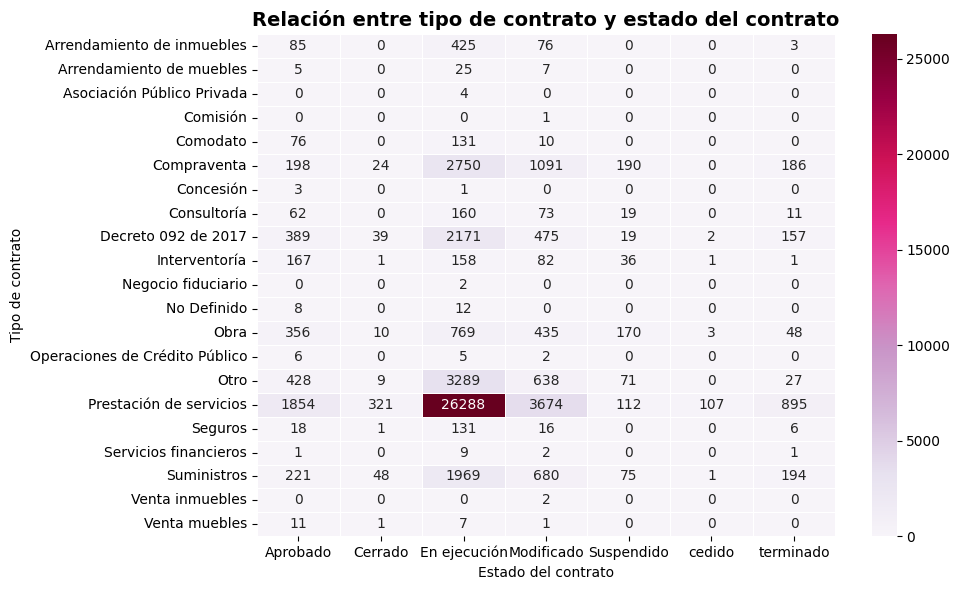

In [75]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot_heatmap,
    annot=True,
    fmt=".0f",
    cmap="PuRd",
    linewidths=0.5
)

plt.title(
    "Relación entre tipo de contrato y estado del contrato",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Estado del contrato")
plt.ylabel("Tipo de contrato")

plt.tight_layout()
plt.show()


Este mapa evidencia una fuerte concentración de contratos de prestación de servicios en estado En ejecución, lo que confirma su carácter operativo y continuo. En contraste, otros tipos como arrendamiento o compraventa presentan menor volumen y una mayor proporción de contratos cerrados, reflejando su naturaleza puntual. Este patrón sugiere que el tipo de contrato es un factor relevante para predecir el estado del mismo.

### 4.5 Valor del contrato por tipo (Top 5)

Este boxplot permite analizar cómo se distribuyen los valores de los contratos según su tipo, identificando la mediana, la dispersión y la presencia de valores atípicos. A través de esta visualización es posible comparar no solo el valor típico de los contratos en cada categoría, sino también la variabilidad existente entre ellos, lo que aporta información clave sobre qué tipos de contrato tienden a concentrar mayores montos y cuáles presentan una mayor heterogeneidad en sus valores.

In [76]:
from pyspark.sql.functions import regexp_replace

df_valores = df.withColumn(
    "valor_contrato_num",
    regexp_replace("valor_del_contrato", ",", "").cast("double")
)

top_tipos = (
    df_valores
    .groupBy("tipo_de_contrato")
    .count()
    .orderBy(col("count").desc())
    .limit(5)
    .select("tipo_de_contrato")
)

df_box = (
    df_valores
    .join(top_tipos, on="tipo_de_contrato")
    .select("tipo_de_contrato", "valor_contrato_num")
    .dropna()
    .toPandas()
)


/tmp/ipykernel_2677/3634323811.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


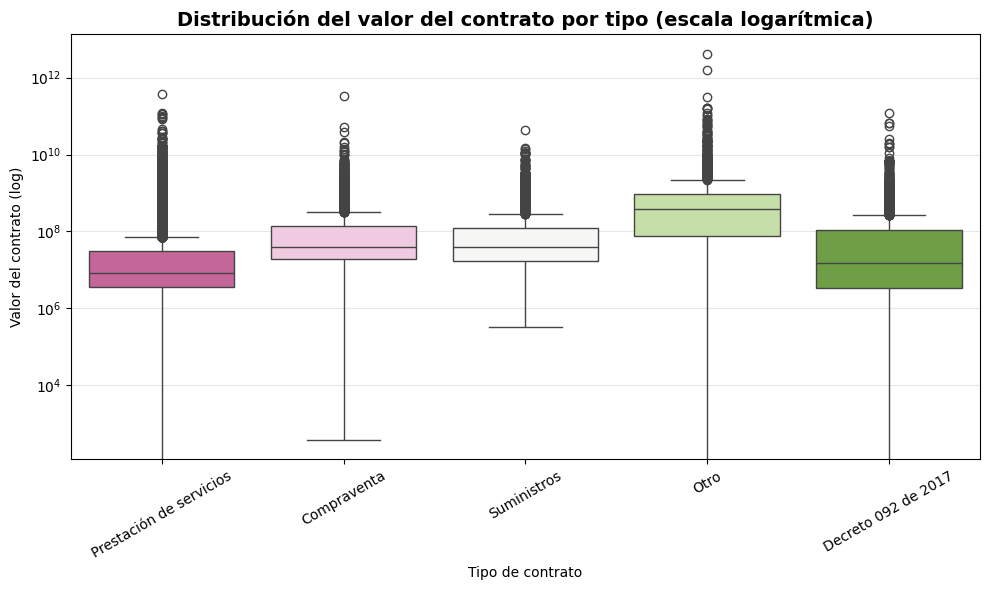

In [77]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_box,
    x="tipo_de_contrato",
    y="valor_contrato_num",
    palette="PiYG",
    showfliers=True
)

plt.yscale("log")

plt.title(
    "Distribución del valor del contrato por tipo (escala logarítmica)",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Tipo de contrato")
plt.ylabel("Valor del contrato (log)")

plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


El gráfico evidencia diferencias claras en la distribución del valor de los contratos según su tipo, mientras la prestación de servicios, aunque es la más frecuente, se concentra en montos relativamente bajos con algunos valores atípicos elevados, otros tipos como compraventa presentan medianas más altas y mayor dispersión, reflejando contratos de mayor valor y variabilidad. Por su parte, los contratos bajo el Decreto 092 de 2017 muestran una distribución más homogénea y concentrada, lo que sugiere montos estandarizados asociados a su marco normativo. En conjunto, el análisis confirma que el tipo de contrato es un factor determinante en el comportamiento del valor contratado.

## 5. Analizar valores nulos y decidir estrategia

El principal objetivo de esta sección es identificar columnas con valores nulos y definir estrategias de tratamiento (eliminar, imputar, conservar)

In [78]:
from pyspark.sql.functions import isnan, when, count

print("Valores nulos por columna")

null_counts = df.select([
    count(when(isnan(c) | col(c).isNull(), c)).alias(c)
    for c in df.columns
])

null_counts.show(truncate=False)


Valores nulos por columna


+-----------------------+-----------+--------------+------------+------+----------------+------------------+--------------+---------------+
|referencia_del_contrato|nit_entidad|nombre_entidad|departamento|ciudad|tipo_de_contrato|valor_del_contrato|fecha_de_firma|estado_contrato|
+-----------------------+-----------+--------------+------------+------+----------------+------------------+--------------+---------------+
|0                      |0          |0             |0           |0     |0               |0                 |0             |0              |
+-----------------------+-----------+--------------+------------+------+----------------+------------------+--------------+---------------+



Se realizó un análisis de valores nulos en todas las variables del conjunto de datos con el fin de identificar posibles ausencias de información que pudieran afectar la calidad del análisis posterior. Los resultados muestran que ninguna de las columnas presenta valores nulos, es decir, todas registran un conteo de 0 valores faltantes. Este comportamiento indica que el dataset se encuentra completo y correctamente diligenciado. Dado lo anterior, no fue necesario aplicar estrategias de imputación, eliminación o tratamiento de valores nulos, permitiendo avanzar directamente a las siguientes etapas del análisis.


## 6. Explorar la variable objetivo

Entender el comportamiento, dispersión y escala del valor del contrato, variable clave para ML.

In [79]:

from pyspark.sql.functions import col, avg, stddev, min as spark_min, max as spark_max, count, when

valor_cols = [c for c in df.columns if 'valor' in c.lower() or 'precio' in c.lower()]

print("\nColumnas de valor")
for col_name in valor_cols:
    print(f"- {col_name}")

if valor_cols:
    valor_col = valor_cols[0]
    print(f"\nColumna seleccionada para análisis: {valor_col}")

    # Conversión a formato numérico
    df = df.withColumn(valor_col + "_num", col(valor_col).cast("double"))

    print("\nEstadìsticas descriptivas de la variable objeto")
    df.select(
        spark_min(col(valor_col + "_num")).alias("Valor mínimo"),
        spark_max(col(valor_col + "_num")).alias("Valor máximo"),
        avg(col(valor_col + "_num")).alias("Valor promedio"),
        stddev(col(valor_col + "_num")).alias("Desviación estándar")
    ).show()

    print("\nDistribuciòn por rangos del valor del contrato")
    df.select(
        count(when(col(valor_col + "_num") < 10_000_000, True)).alias("Menor a 10M"),
        count(when((col(valor_col + "_num") >= 10_000_000) & (col(valor_col + "_num") < 100_000_000), True)).alias("Entre 10M y 100M"),
        count(when((col(valor_col + "_num") >= 100_000_000) & (col(valor_col + "_num") < 1_000_000_000), True)).alias("Entre 100M y 1B"),
        count(when(col(valor_col + "_num") >= 1_000_000_000, True)).alias("Mayor a 1B")
    ).show()



Columnas de valor
- valor_del_contrato

Columna seleccionada para análisis: valor_del_contrato

Estadìsticas descriptivas de la variable objeto
+------------+-----------------+--------------------+--------------------+
|Valor mínimo|     Valor máximo|      Valor promedio| Desviación estándar|
+------------+-----------------+--------------------+--------------------+
|         0.0|4.205027751839E12|5.2151670054863346E8|2.055999607361148...|
+------------+-----------------+--------------------+--------------------+


Distribuciòn por rangos del valor del contrato
+-----------+----------------+---------------+----------+
|Menor a 10M|Entre 10M y 100M|Entre 100M y 1B|Mayor a 1B|
+-----------+----------------+---------------+----------+
|      20910|           20687|           7998|      2653|
+-----------+----------------+---------------+----------+



La variable objetivo del análisis corresponde al valor del contrato. A partir del análisis estadístico descriptivo, se observa que el conjunto de datos cuenta con 52.248 contratos, lo que proporciona una base suficiente para realizar inferencias. El valor promedio del contrato es de aproximadamente 521 millones, sin embargo, este valor debe interpretarse con cuidado debido a la alta dispersión en los datos, evidenciada por una desviación estándar significativamente elevada.

El valor mínimo registrado es 0, lo que sugiere la existencia de contratos sin valor económico, mientras que el valor máximo alcanza cifras del orden de 4205 millones, indicando la presencia de contratos de gran magnitud. Esta amplia diferencia entre valores mínimos y máximos revela una distribución altamente asimétrica.

En conjunto, estos resultados indican que el valor del contrato presenta una fuerte variabilidad y presencia de valores extremos, lo cual justifica el uso de escalas logarítmicas y métodos de detección de outliers en etapas posteriores del análisis.

## 7. Analizar distribución por departamento




Columna de departamento utilizada: departamento

Top 10 departamentos x No. de contrato


+--------------------------+-------------+------------------+
|departamento              |num_contratos|valor_total       |
+--------------------------+-------------+------------------+
|Distrito Capital de Bogotá|14569        |1.6228824953402E13|
|Valle del Cauca           |6013         |8.7804974281E11   |
|Antioquia                 |3982         |1.733880448534E12 |
|Magdalena                 |3042         |1.155945693334E12 |
|Cundinamarca              |2696         |6.74487784139E11  |
|Santander                 |2366         |8.06339772989E11  |
|Boyacá                    |1828         |3.79026346043E11  |
|Tolima                    |1630         |3.06303914269E11  |
|No Definido               |1611         |1.84797478088E11  |
|Meta                      |1376         |3.00018809992E11  |
+--------------------------+-------------+------------------+



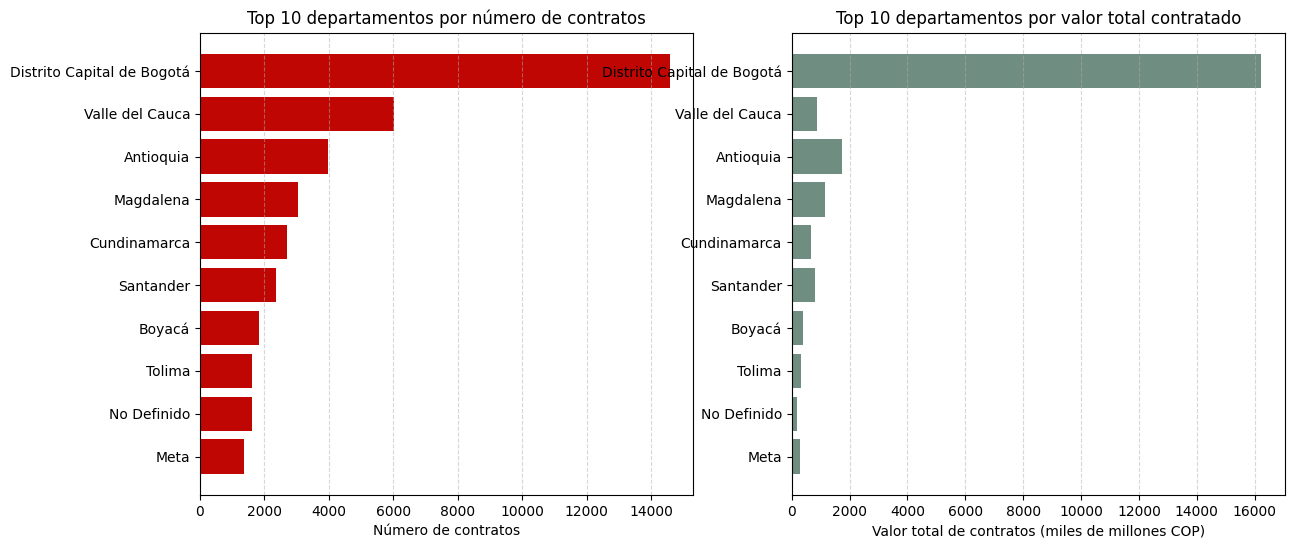

In [86]:

from pyspark.sql.functions import col, count, sum as spark_sum, desc
import matplotlib.pyplot as plt

dept_cols = [c for c in df.columns if 'departamento' in c.lower()]

if dept_cols:
    dept_col = dept_cols[0]
    print(f"\nColumna de departamento utilizada: {dept_col}")

    # Limpiar posibles valores vacíos
    df_dept_clean = df.filter(
        col(dept_col).isNotNull() & (col(dept_col) != "")
    )

    print("\nTop 10 departamentos x No. de contrato")
    df_dept = (
        df_dept_clean
        .groupBy(dept_col)
        .agg(
            count("*").alias("num_contratos"),
            spark_sum(col(valor_col + "_num")).alias("valor_total")
        )
        .orderBy(desc("num_contratos"))
        .limit(10)
    )

    df_dept.show(truncate=False)

    df_dept_pandas = df_dept.toPandas()
    plt.figure(figsize=(14, 6))

    # Gráfico 1: Número de contratos
    plt.subplot(1, 2, 1)
    plt.barh(
        df_dept_pandas[dept_col],
        df_dept_pandas["num_contratos"],
        color="#bf0603"
    )
    plt.xlabel("Número de contratos")
    plt.title("Top 10 departamentos por número de contratos")
    plt.gca().invert_yaxis()
    plt.grid(axis="x", linestyle="--", alpha=0.5)
  

    # Gráfico 2: Valor total de contratos
    plt.subplot(1, 2, 2)
    plt.barh(
        df_dept_pandas[dept_col],
        df_dept_pandas["valor_total"] / 1e9,
        color="#708d81"
    )
    plt.xlabel("Valor total de contratos (miles de millones COP)")
    plt.title("Top 10 departamentos por valor total contratado")
    plt.gca().invert_yaxis()
    plt.grid(axis="x", linestyle="--", alpha=0.5)
    



El análisis por departamento evidencia una alta concentración de la contratación pública en el Distrito Capital de Bogotá, el cual lidera tanto en número de contratos (14.569) como en valor total contratado, superando de manera significativa al resto del país. Por otro lado se encuentran departamentos como Valle del Cauca, Antioquia y Magdalena, que si bien presentan un volumen considerable de contratos, están muy por debajo de Bogotá. Este comportamiento sugiere una centralización administrativa, posiblemente asociada a la ubicación de entidades nacionales y grandes organismos públicos en la capital. Asimismo, se observa que algunos departamentos con un número moderado de contratos no necesariamente concentran altos valores totales, lo que indica heterogeneidad en el tamaño promedio de los contratos y diferencias en el tipo de proyectos ejecutados a nivel territorial. En general estos resultados reflejan una distribución desigual de la contratación pública entre los departamentos, tanto en cantidad como en recursos.

## 8. Explorar tipo de contrato y estado
### 8.1 Diagrama de pareto del tipo de contrato (frecuencia acumulada)

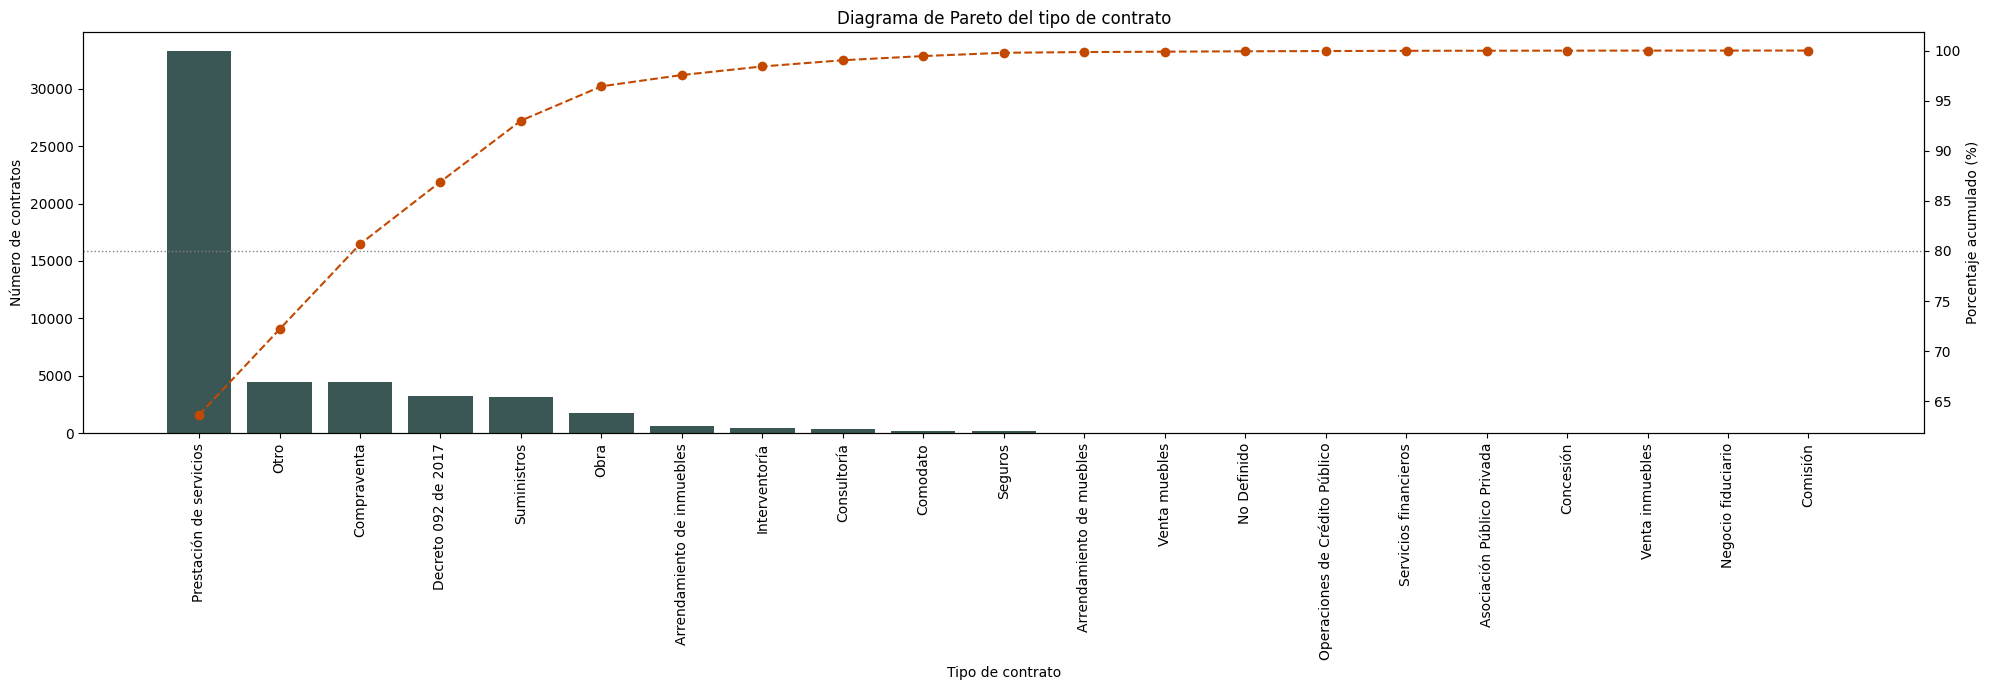

In [107]:
# %%
# Pareto: Tipo de contrato

df_tipo = (
    df.groupBy(tipo_col)
      .agg(count("*").alias("num_contratos"))
      .orderBy(desc("num_contratos"))
)

df_tipo_pd = df_tipo.toPandas()

# Cálculo acumulado
df_tipo_pd["porcentaje"] = df_tipo_pd["num_contratos"] / df_tipo_pd["num_contratos"].sum() * 100
df_tipo_pd["porcentaje_acum"] = df_tipo_pd["porcentaje"].cumsum()

# Visualización
fig, ax1 = plt.subplots(figsize=(20, 7))

ax1.bar(
    df_tipo_pd[tipo_col],
    df_tipo_pd["num_contratos"],
    alpha=0.85,
    color="#183a37"
)
ax1.set_ylabel("Número de contratos")
ax1.set_xlabel("Tipo de contrato")
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()
ax2.plot(
    df_tipo_pd[tipo_col],
    df_tipo_pd["porcentaje_acum"],
    marker="o",
    linestyle="--",
     color="#c44900"
)
ax2.set_ylabel("Porcentaje acumulado (%)")
ax2.axhline(80, linestyle=":", linewidth=1, color="gray")

plt.title("Diagrama de Pareto del tipo de contrato")
plt.tight_layout()
plt.show()



El diagrama evidencia una alta concentración de contratos en pocos tipos contractuales. En particular, la Prestación de servicios domina la distribución, representando por sí sola una proporción significativa del total de contratos. Al analizar el porcentaje acumulado, se observa que los primeros cuatro o cinco tipos de contrato concentran más del 80% del total, lo que confirma el principio de Pareto (80/20). Esto sugiere que la actividad contractual está fuertemente focalizada en modalidades específicas, mientras que el resto de los tipos de contrato tienen una participación marginal.

## 9. Detectar outliers con método IQR

In [109]:

if valor_cols:
    print("\nDetección de outliers")

    valor_num_col = valor_col + "_num"
    percentiles = df.approxQuantile(
        valor_num_col,
        [0.25, 0.50, 0.75, 0.95, 0.99],
        0.01
    )

    q1, q2, q3, p95, p99 = percentiles

    print(f"Q1 (25%): ${q1:,.2f}")
    print(f"Q2 / Mediana (50%): ${q2:,.2f}")
    print(f"Q3 (75%): ${q3:,.2f}")
    print(f"P95 (95%): ${p95:,.2f}")
    print(f"P99 (99%): ${p99:,.2f}")

    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    print(f"\nRango esperado según IQR:")
    print(f"Desde ${lower_bound:,.2f} hasta ${upper_bound:,.2f}")

    # Identificación de outliers
    df_outliers = df.filter(
        (col(valor_num_col) < lower_bound) |
        (col(valor_num_col) > upper_bound)
    )

    total_registros = df.count()
    num_outliers = df_outliers.count()
    porcentaje_outliers = (num_outliers / total_registros) * 100

    print(f"\nOutliers detectados: {num_outliers:,}")
    print(f"Porcentaje sobre el total: {porcentaje_outliers:.2f}%")




Detección de outliers


Q1 (25%): $4,500,000.00
Q2 / Mediana (50%): $17,929,833.00
Q3 (75%): $60,331,617.00
P95 (95%): $824,888,565.00
P99 (99%): $4,205,027,751,839.00

Rango esperado según IQR:
Desde $-79,247,425.50 hasta $144,079,042.50



Outliers detectados: 8,841
Porcentaje sobre el total: 16.92%


El análisis de valores atípicos en el valor de los contratos muestra que la distribución está fuertemente concentrada en montos bajos y medianos, mientras que existe un grupo reducido de contratos con valores significativamente más altos. Aunque la mayoría de los contratos se encuentra dentro de un rango esperado, aproximadamente el 17% presenta valores que se consideran atípicos según el método IQR, lo que evidencia una alta dispersión en los montos contratados.

## 10. Bonus: Análisis temporal

In [110]:

from pyspark.sql.functions import to_date, year, month

fecha_cols = [c for c in df.columns if 'fecha' in c.lower()]

if fecha_cols:
    fecha_col = fecha_cols[0]
    print(f"\nAnálisis temporal")
    print(f"Columna de fecha utilizada: {fecha_col}")

    df = df.withColumn(
        fecha_col + "_parsed",
        to_date(col(fecha_col))
    )

    df = df.withColumn("anio", year(col(fecha_col + "_parsed")))
    df = df.withColumn("mes", month(col(fecha_col + "_parsed")))

    print("\nContratos por año")
    df.groupBy("anio") \
        .agg(count("*").alias("num_contratos")) \
        .orderBy("anio") \
        .show(truncate=False)



Análisis temporal
Columna de fecha utilizada: fecha_de_firma

Contratos por año


+----+-------------+
|anio|num_contratos|
+----+-------------+
|2025|52248        |
+----+-------------+



El análisis temporal muestra que la totalidad de los contratos analizados se concentran en el año 2025. Este comportamiento se explica por el filtro aplicado durante la fase de ingesta de datos, donde se seleccionaron únicamente contratos firmados dentro de ese periodo. 


## 11. Resumen final del EDA

In [112]:

print("Resumen del análisis exploratorio")
total_registros = df.count()
print(f"✓ Total de registros analizados: {total_registros:,}")
print(f"✓ Total de columnas: {len(df.columns)}")

if valor_cols:
    total_valor = df.select(
        spark_sum(col(valor_col + "_num")).alias("valor_total")
    ).collect()[0]["valor_total"]

    if total_valor:
        print(f"✓ Valor total contratado: ${total_valor:,.2f}")

print("✓ Análisis por departamento: Completado")
print("✓ Análisis por tipo y estado de contrato: Completado")
print("✓ Detección de outliers: Completado")
print("✓ Análisis temporal: Completado")
print("✓ Visualizaciones generadas en /opt/spark-data/processed/")


Resumen del análisis exploratorio
✓ Total de registros analizados: 52,248
✓ Total de columnas: 13
✓ Valor total contratado: $27,248,204,570,265.00
✓ Análisis por departamento: Completado
✓ Análisis por tipo y estado de contrato: Completado
✓ Detección de outliers: Completado
✓ Análisis temporal: Completado
✓ Visualizaciones generadas en /opt/spark-data/processed/


En conclusión, el análisis exploratorio permitió comprender la estructura y comportamiento del conjunto de datos de contratos públicos, identificando patrones relevantes en el valor de los contratos, su distribución por tipo, estado y territorio, así como la presencia de valores atípicos significativos. Los resultados evidencian una alta concentración de contratos de bajo valor junto con un reducido número de contratos de montos excepcionalmente altos, lo cual justifica la necesidad de estrategias de tratamiento de outliers en fases posteriores. Este análisis sienta una base sólida para los siguientes pasos de transformación y modelado de los datos.


In [113]:
output_path = "/opt/spark-data/processed/secop_eda.parquet"

df.write \
  .mode("overwrite") \
  .parquet(output_path)

print(f"\nDataset limpio guardado en: {output_path}")

spark.stop()
print("SparkSession finalizada correctamente")


Dataset limpio guardado en: /opt/spark-data/processed/secop_eda.parquet
SparkSession finalizada correctamente
